# Loan Approval Prediction System for Banking & Financial Analytics
### Silver Oak University — BCA Semester 7: Computational Analytics
**Academic Curriculum Mapping:**
- **Unit 1: Data Foundations & Quality** (Collection, Ingestion, Auditing, Statistics, Correlation)
- **Unit 2: Data Preprocessing & EDA** (Missing Value Imputation, Outlier Detection, Scaling, Visualizations)
- **Unit 3: Predictive Analytics & ML** (Feature Engineering, SMOTE, Classification, Cross-Validation, Metrics)
- **Unit 4: Business Intelligence & Decision Support** (Feature Importance, Underwriting Tiers, Decision Engine)

---
### 📌 Important Methodological Clarification:
The target column in this dataset is `Loan_Status`:
- `'Y'` = **Loan Approved**
- `'N'` = **Loan Not Approved / Rejected**

This represents an **underwriting approval decision** at the pre-disbursement stage, **NOT** an observed post-disbursement default event. Rejected applicants never received loan funds and therefore cannot be characterized as loan defaulters. To maintain full academic and statistical integrity, this project models **Loan Approval Eligibility**.


## 1. System Setup & Scientific Library Imports
Importing computational analytics and machine learning libraries: `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `imbalanced-learn`, and `xgboost`.


In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE

# Aesthetics
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline
print("All scientific libraries imported successfully!")


All scientific libraries imported successfully!


## 2. Phase 1 — Data Acquisition & Initial Inspection (Unit 1)
Loading the verified loan dataset from `data/loan_data.csv` and inspecting its dimensions, columns, data types, and initial records.


In [2]:
data_path = os.path.join("..", "data", "loan_data.csv")
df_raw = pd.read_csv(data_path)

print(f"Dataset Shape: {df_raw.shape[0]} Rows, {df_raw.shape[1]} Columns\n")
print("Column Names and Data Types:")
print(df_raw.dtypes)
print("\nFirst 5 Records:")
df_raw.head()


Dataset Shape: 614 Rows, 13 Columns

Column Names and Data Types:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

First 5 Records:


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Phase 2 — Data Quality & Integrity Audit (Unit 1 & Unit 2)
Auditing missing values per attribute, duplicate records, and target class distribution.


In [3]:
# Missing value analysis
missing_count = df_raw.isnull().sum()
missing_pct = (missing_count / len(df_raw)) * 100
quality_df = pd.DataFrame({'Missing Count': missing_count, 'Percentage (%)': missing_pct.round(2)})
print("=== Missing Values Audit ===")
display(quality_df[quality_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

print(f"\nDuplicate Records: {df_raw.duplicated().sum()}")

print("\n=== Target Variable Analysis (Loan_Status) ===")
print(df_raw['Loan_Status'].value_counts())
print("\nProportions (%):")
print((df_raw['Loan_Status'].value_counts(normalize=True) * 100).round(2))


=== Missing Values Audit ===


,Missing Count,Percentage (%)
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49



Duplicate Records: 0

=== Target Variable Analysis (Loan_Status) ===
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Proportions (%):
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


## 4. Data Cleaning & Outlier Treatment (Unit 2)
- Dropping `Loan_ID` (uninformative primary key)
- Standardizing `Dependents` ('3+' -> 3)
- Imputing missing numerical values via **Median** (robust against outliers)
- Imputing missing categorical values via **Mode** (most frequent class)


In [4]:
df_clean = df_raw.copy()

# Drop identifier
if 'Loan_ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['Loan_ID'])

# Standardize Dependents
df_clean['Dependents'] = df_clean['Dependents'].replace({'3+': '3'})

# Impute Categorical variables with Mode
cat_impute = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']
for col in cat_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# Impute Numerical variables with Median
num_impute = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']
for col in num_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean['Dependents'] = df_clean['Dependents'].astype(int)
df_clean['Credit_History'] = df_clean['Credit_History'].astype(int)

print("Remaining Missing Values after Cleaning:", df_clean.isnull().sum().sum())


Remaining Missing Values after Cleaning: 0


## 5. Phase 5 — Feature Engineering (Unit 3)
Creating domain-justified financial and debt ratios:
1. `Total_Income`: Combined earning capacity of applicant and coapplicant.
2. `Loan_to_Income_Ratio`: Debt leverage index relative to total annual earnings.
3. `Monthly_EMI_Proxy`: Estimated monthly installment obligation.
4. `EMI_to_Income_Ratio`: Proportion of monthly income consumed by loan repayments.
5. `Income_Per_Dependent`: Disposable family income per household dependent.


In [5]:
df_fe = df_clean.copy()

# 1. Total Household Income
df_fe['Total_Income'] = df_fe['ApplicantIncome'] + df_fe['CoapplicantIncome']

# 2. Loan to Income Ratio
df_fe['Loan_to_Income_Ratio'] = df_fe['LoanAmount'] / (df_fe['Total_Income'] / 1000.0 + 1e-5)

# 3. Monthly EMI Proxy
df_fe['Monthly_EMI_Proxy'] = (df_fe['LoanAmount'] * 1000.0) / (df_fe['Loan_Amount_Term'] + 1e-5)

# 4. EMI to Monthly Income Ratio
monthly_income = (df_fe['Total_Income'] / 12.0) + 1e-5
df_fe['EMI_to_Income_Ratio'] = df_fe['Monthly_EMI_Proxy'] / monthly_income

# 5. Income per Dependent
df_fe['Income_Per_Dependent'] = df_fe['Total_Income'] / (df_fe['Dependents'] + 1)

df_fe[['Total_Income', 'Loan_to_Income_Ratio', 'Monthly_EMI_Proxy', 'EMI_to_Income_Ratio', 'Income_Per_Dependent']].head()


,Total_Income,Loan_to_Income_Ratio,Monthly_EMI_Proxy,EMI_to_Income_Ratio,Income_Per_Dependent
0,5849.0,21.884045,355.555546,0.729469,5849.0
1,6091.0,21.014577,355.555546,0.700487,3045.5
2,3000.0,21.999927,183.333328,0.733333,3000.0
3,4941.0,24.286533,333.333324,0.809553,4941.0
4,6000.0,23.499961,391.666656,0.783333,6000.0


## 6. Phase 3 — Exploratory Data Analysis & Visualizations (Unit 2)
Analyzing approval distributions, credit history influence, and financial correlations.


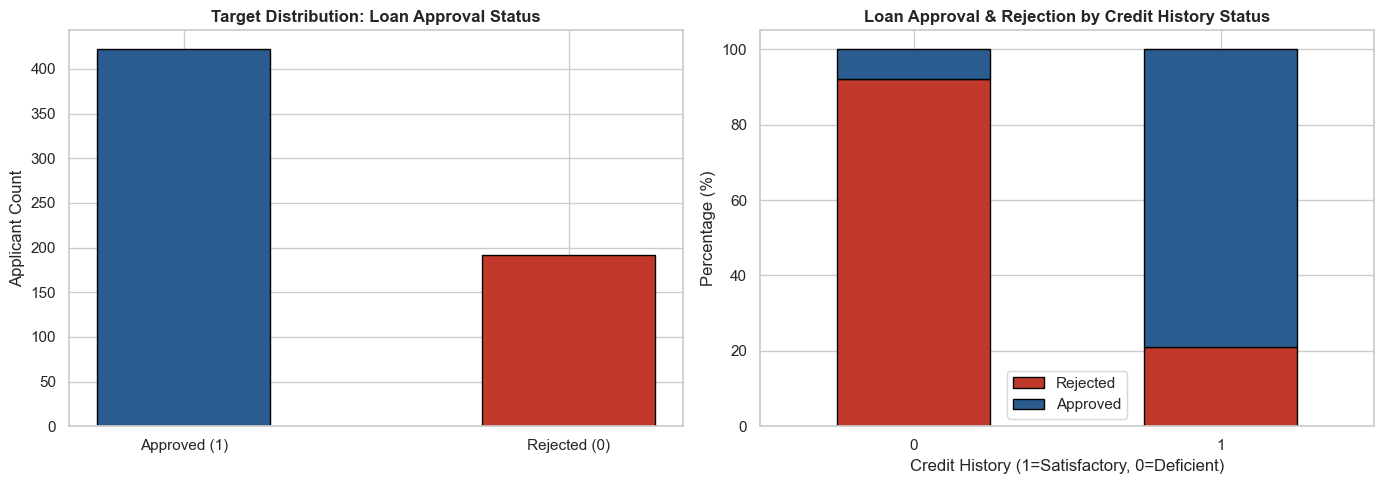

In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
counts = df_fe['Loan_Status'].value_counts()
plt.bar(['Approved (1)', 'Rejected (0)'], [counts['Y'], counts['N']], color=['#2b5c8f', '#c0392b'], width=0.45, edgecolor='black')
plt.title("Target Distribution: Loan Approval Status", weight='bold')
plt.ylabel("Applicant Count")

plt.subplot(1, 2, 2)
credit_cross = pd.crosstab(df_fe['Credit_History'], df_fe['Loan_Status'], normalize='index') * 100
credit_cross.plot(kind='bar', stacked=True, color=['#c0392b', '#2b5c8f'], ax=plt.gca(), edgecolor='black')
plt.title("Loan Approval & Rejection by Credit History Status", weight='bold')
plt.xlabel("Credit History (1=Satisfactory, 0=Deficient)")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(["Rejected", "Approved"])
plt.tight_layout()
plt.show()


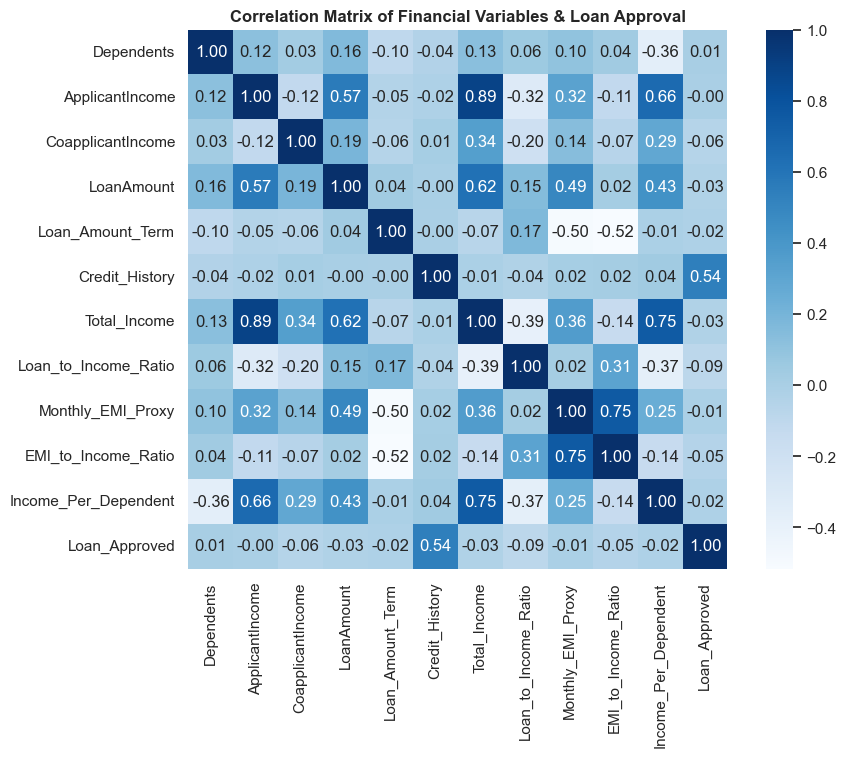

In [7]:
# Correlation Heatmap
plt.figure(figsize=(10, 7))
df_num = df_fe.select_dtypes(include=[np.number]).copy()
df_num['Loan_Approved'] = df_fe['Loan_Status'].map({'Y': 1, 'N': 0})
sns.heatmap(df_num.corr(), annot=True, fmt='.2f', cmap='Blues', cbar=True, square=True)
plt.title("Correlation Matrix of Financial Variables & Loan Approval", weight='bold')
plt.show()


## 7. Phase 4 — Preprocessing & Strict Data Leakage Prevention (Unit 2 & 3)
- Mapping target: `1 = Approved ('Y')`, `0 = Rejected ('N')`
- Encoding nominal categoricals via One-Hot Encoding
- Splitting data into **80% Training** and **20% Unseen Test** partition (Stratified)
- Fitting `StandardScaler` **strictly** on the training partition
- Applying **SMOTE** (Synthetic Minority Over-sampling Technique) **only** on the training data to balance the minority Rejected class with the Approved class


In [8]:
# Target encoding: 1 = Approved, 0 = Rejected
y = df_fe['Loan_Status'].map({'Y': 1, 'N': 0}).astype(int)
X = df_fe.drop(columns=['Loan_Status'])

# One-hot encode categoricals
cat_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area']
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train/Test Split FIRST (Strict Leakage Prevention)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training split: {X_train.shape}, Test split: {X_test.shape}")
print("Training class counts before SMOTE (0: Rejected, 1: Approved):", y_train.value_counts().to_dict())

# Scale features based only on training statistics
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# Apply SMOTE ONLY on training partition
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Training class counts after SMOTE:", pd.Series(y_train_smote).value_counts().to_dict())
print("Test class counts remain unaltered:", y_test.value_counts().to_dict())


Training split: (491, 17), Test split: (123, 17)
Training class counts before SMOTE (0: Rejected, 1: Approved): {1: 337, 0: 154}


Training class counts after SMOTE: {1: 337, 0: 337}
Test class counts remain unaltered: {1: 85, 0: 38}


## 8. Phase 6 & 7 — Model Training, Cross-Validation & Evaluation (Unit 3)
Training three supervised learning classifiers:
1. **Logistic Regression** (Linear baseline)
2. **Random Forest Classifier** (Ensemble Bagging)
3. **XGBoost Classifier** (Gradient Boosted Trees)

Evaluating on unseen test data across:
- **Accuracy**
- **Precision (Approved)**
- **Recall (Approved)**
- **F1-Score (Approved & Rejected)**
- **ROC-AUC**
- **5-Fold Stratified Cross-Validation F1**


In [9]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=6, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, eval_metric="logloss", random_state=42)
}

results = []
trained_models = {}
cv_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    # Train on SMOTE balanced data
    model.fit(X_train_smote, y_train_smote)
    trained_models[name] = model
    
    # 5-Fold Cross Validation
    cv_scores = cross_val_score(model, X_train_smote, y_train_smote, cv=cv_kfold, scoring='f1')
    
    # Predict on unseen test data
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None
    
    acc = accuracy_score(y_test, y_pred)
    prec_app = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec_app = recall_score(y_test, y_pred, pos_label=1)
    f1_app = f1_score(y_test, y_pred, pos_label=1)
    f1_rej = f1_score(y_test, y_pred, pos_label=0)
    roc_auc = roc_auc_score(y_test, y_proba) if y_proba is not None else 0.0
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision (Approved)": round(prec_app, 4),
        "Recall (Approved)": round(rec_app, 4),
        "F1-Score (Approved)": round(f1_app, 4),
        "F1-Score (Rejected)": round(f1_rej, 4),
        "ROC-AUC": round(roc_auc, 4),
        "CV-5Fold F1": round(np.mean(cv_scores), 4)
    })

comparison_df = pd.DataFrame(results)
display(comparison_df)


,Model,Accuracy,Precision (Approved),Recall (Approved),F1-Score (Approved),F1-Score (Rejected),ROC-AUC,CV-5Fold F1
0,Logistic Regression,0.8049,0.8506,0.8706,0.8605,0.6757,0.8613,0.7260
1,Random Forest,0.8211,0.8706,0.8706,0.8706,0.7105,0.8533,0.7667
2,XGBoost,0.7967,0.8488,0.8588,0.8538,0.6667,0.8375,0.7704


## 9. Diagnostic Evaluation: Confusion Matrices & ROC Curves (Unit 3)


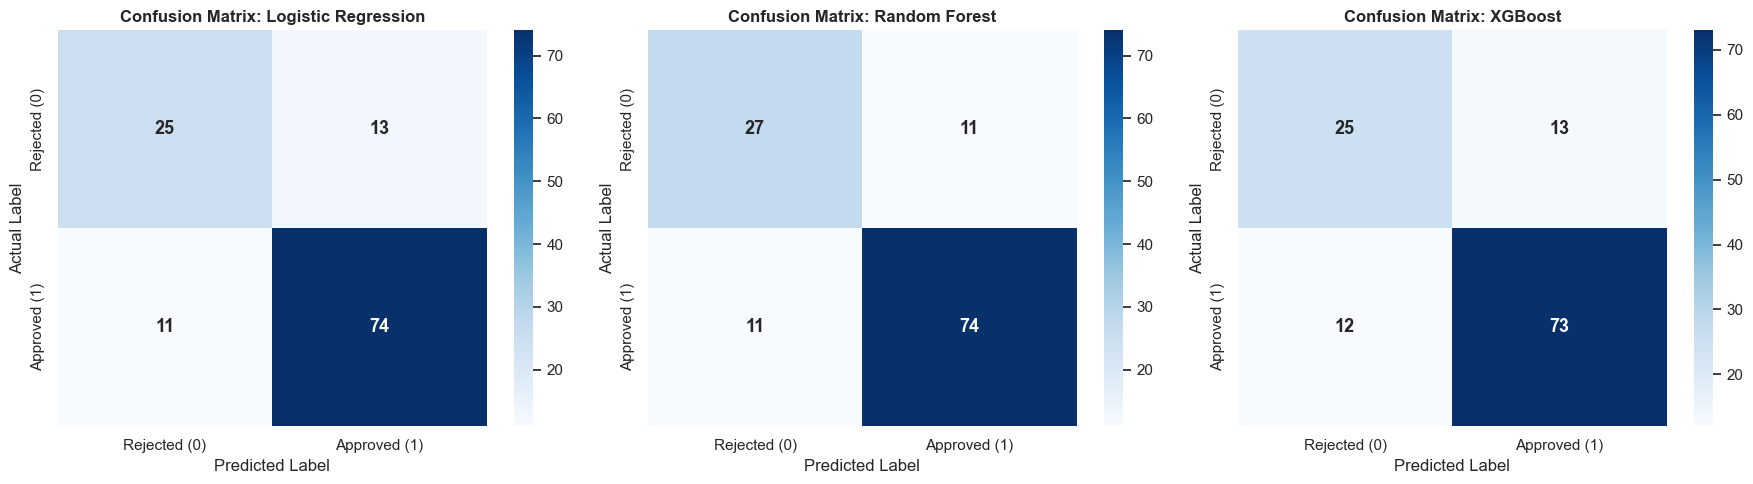

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_labels = ["Rejected (0)", "Approved (1)"]

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=class_labels, yticklabels=class_labels, annot_kws={"size": 13, "weight": "bold"})
    axes[idx].set_title(f"Confusion Matrix: {name}", weight='bold')
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("Actual Label")

plt.tight_layout()
plt.show()


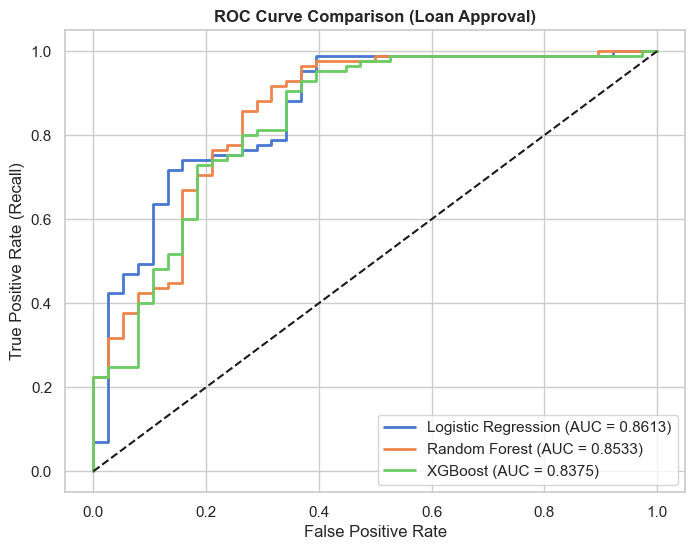

In [11]:
plt.figure(figsize=(8, 6))
for name, model in trained_models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.4f})", lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison (Loan Approval)", weight='bold')
plt.legend()
plt.show()


## 10. Phase 8 — Feature Importance & Model Explainability (Unit 4)
Extracting feature importance from Random Forest to examine which factors drive loan approval decisions.


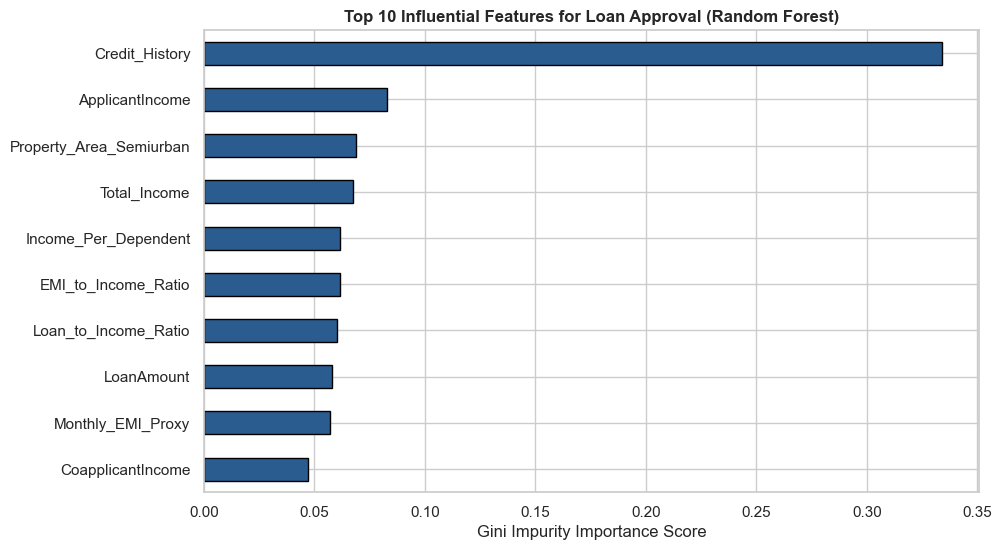

In [12]:
rf_model = trained_models["Random Forest"]
feat_importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_importances.head(10).plot(kind='barh', color='#2b5c8f', edgecolor='black')
plt.gca().invert_yaxis()
plt.title("Top 10 Influential Features for Loan Approval (Random Forest)", weight='bold')
plt.xlabel("Gini Impurity Importance Score")
plt.show()


## 11. Phase 10 — Applicant Loan Approval Simulator (Unit 4)
Demonstrating real-time underwriting simulation with approval probability, predicted class, and transparent eligibility tiers.


In [13]:
def evaluate_applicant(income, coapp_income, loan_amnt, term, credit_hist, property_area='Semiurban'):
    # Derived features
    tot_inc = income + coapp_income
    lti = loan_amnt / (tot_inc / 1000.0 + 1e-5)
    emi = (loan_amnt * 1000.0) / (term + 1e-5)
    emi_ratio = emi / ((tot_inc / 12.0) + 1e-5)
    inc_dep = tot_inc / (0 + 1)
    
    # Form input dictionary
    row = {
        'Dependents': 0, 'ApplicantIncome': income, 'CoapplicantIncome': coapp_income,
        'LoanAmount': loan_amnt, 'Loan_Amount_Term': term, 'Credit_History': credit_hist,
        'Total_Income': tot_inc, 'Loan_to_Income_Ratio': lti, 'Monthly_EMI_Proxy': emi,
        'EMI_to_Income_Ratio': emi_ratio, 'Income_Per_Dependent': inc_dep,
        'Gender_Male': 1, 'Married_Yes': 1, 'Education_Not Graduate': 0, 'Self_Employed_Yes': 0,
        'Property_Area_Semiurban': 1 if property_area == 'Semiurban' else 0,
        'Property_Area_Urban': 1 if property_area == 'Urban' else 0
    }
    
    df_single = pd.DataFrame([row])[X_train.columns]
    df_s = pd.DataFrame(scaler.transform(df_single), columns=X_train.columns)
    
    proba = trained_models["Random Forest"].predict_proba(df_s)[0]
    app_prob = proba[1]
    
    tier = "High Approval Likelihood" if app_prob >= 0.70 else "Moderate Approval Likelihood" if app_prob >= 0.50 else "Low Approval Likelihood"
    return {
        "Approval Probability": f"{app_prob * 100:.2f}%",
        "Rejection Probability": f"{(1 - app_prob) * 100:.2f}%",
        "Assigned Eligibility Tier": tier,
        "Predicted Decision": "Loan Approved" if app_prob >= 0.5 else "Loan Rejected"
    }

print("=== Sample 1: Strong Credit & Income Profile ===")
print(evaluate_applicant(income=6000, coapp_income=2000, loan_amnt=120, term=360, credit_hist=1.0))

print("\n=== Sample 2: Deficient Credit Profile ===")
print(evaluate_applicant(income=2500, coapp_income=0, loan_amnt=200, term=360, credit_hist=0.0))


=== Sample 1: Strong Credit & Income Profile ===
{'Approval Probability': '66.59%', 'Rejection Probability': '33.41%', 'Assigned Eligibility Tier': 'Moderate Approval Likelihood', 'Predicted Decision': 'Loan Approved'}

=== Sample 2: Deficient Credit Profile ===
{'Approval Probability': '27.79%', 'Rejection Probability': '72.21%', 'Assigned Eligibility Tier': 'Low Approval Likelihood', 'Predicted Decision': 'Loan Rejected'}
